In [52]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

Berikut adalah kenapa kita perlu mengimport bagian ini karena merupakan library python yang digunakan untuk pengolahan citra digital. 'numpy' digunakan untuk operasi numerik, 'matplotlib.pyplot' digunakan untuk menampilkan gambar atau grafik, cv2 digunakan khusus untuk pengolahan citra & video, seperti mengedit gambar atau mendeteksi objek

Proses 1 dibutuhkan karena kode ini berfungsi untuk menampilkan gambar dengan warna yang akurat. Pertama, cv.imread memuat gambar, namun OpenCV menggunakan format warna BGR secara bawaan. Jika langsung ditampilkan, warna gambar akan terlihat aneh atau terbalik. Untuk memperbaikinya, cv.cvtColor mengubah format tersebut menjadi RGB agar sesuai dengan standar pustaka Matplotlib. Terakhir, plt.imshow menampilkan hasil akhir matriks gambar tersebut ke layar dengan warna yang natural sesuai aslinya.

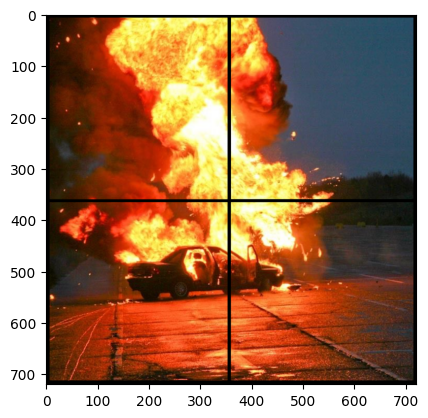

In [53]:
citra = cv.imread("Assets/Meledak.png")
citra = cv.cvtColor(citra, cv.COLOR_BGR2RGB)
plt.imshow(citra)

Proses 2 dibutuhkan karena kode ini berfungsi untuk membagi sebuah citra menjadi empat bagian (kuadran) melalui fungsi kustom bernama clip. Fungsi tersebut menentukan batas pemotongan dengan menghitung koordinat awal dan akhir berdasarkan parameter input, p1 (atas), p2 (bawah), p3 (kiri), dan p4 (kanan). Dengan memberikan nilai margin yang besar pada sisi-sisi tertentu, kode tersebut secara efektif memotong sebagian besar area gambar dan hanya menyisakan area sudut tertentu. Hasilnya, variabel c1 hingga c4 menyimpan potongan gambar untuk sudut kiri atas, kanan atas, kiri bawah, dan kanan bawah.

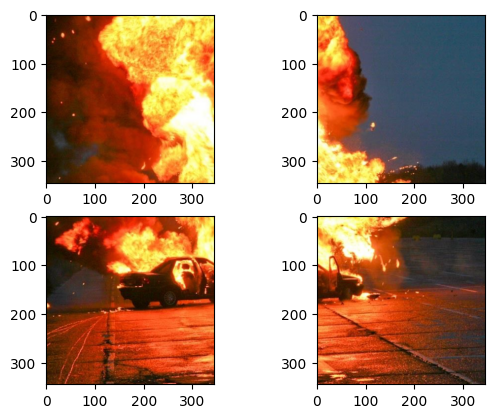

In [54]:

def clip(img, p1=0, p2=0, p3=0, p4=0):
    h, w = img.shape[:2]

    sy, ey = max(0, p1), min(h, h - p2)
    sx, ex = max(0, p3), min(w, w - p4)

    return img[sy:ey, sx:ex]

c1 = clip(citra, 8, 367, 8, 367)
c2 = clip(citra, 8, 367, 367, 8)
c3 = clip(citra, 367, 8, 8, 367)
c4 = clip(citra, 367, 8, 367, 8)

plt.subplot(2,2,1)
plt.imshow(c1)
plt.subplot(2,2,2)
plt.imshow(c2)
plt.subplot(2,2,3)
plt.imshow(c3)
plt.subplot(2,2,4)
plt.imshow(c4)


penggabungan

Proses 3 dibutuhkan karena kode ini berfungsi untuk menggabungkan gambar. Fungsi merge_image bekerja dengan membuat "kanvas" kosong menggunakan np.zeros yang ukurannya disesuaikan dengan total dimensi dua gambar yang akan disatukan. Jika mode horizontal ('H') dipilih, lebar kedua gambar akan dijumlahkan, jika vertikal, maka tingginya yang dijumlahkan. Setelah kanvas siap, data piksel dari tiap gambar ditempelkan ke koordinat yang tepat secara berurutan. Potongan c1 sampai c4 digabung secara horizontal terlebih dahulu menjadi dua baris, lalu kedua baris tersebut ditumpuk secara vertikal untuk menyusun kembali gambar utuh yang telah dipotong.

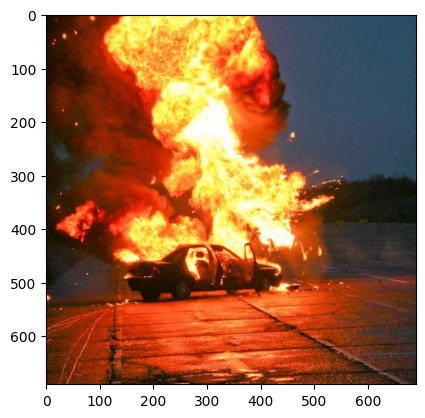

In [55]:
def merge_image(citra1, citra2, posisi='H'):

    if posisi == 'H':

        tinggi = max(citra1.shape[0], citra2.shape[0])
        lebar_total = citra1.shape[1] + citra2.shape[1]

        if len(citra1.shape) == 2:

            gabungan = np.zeros((tinggi, lebar_total),
                                dtype=citra1.dtype)
        else:

            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]),
                                dtype=citra1.dtype)
        gabungan[0:citra1.shape[0],
                 0:citra1.shape[1]] = citra1

        gabungan[0:citra2.shape[0],
                 citra1.shape[1]:citra1.shape[1] + citra2.shape[1]] = citra2
    else:

        tinggi_total = citra1.shape[0] + citra2.shape[0]
        lebar = max(citra1.shape[1], citra2.shape[1])
        if len(citra1.shape) == 2:

            gabungan = np.zeros((tinggi_total, lebar),
                                dtype=citra1.dtype)
        else:

            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]),
                                dtype=citra1.dtype)
        gabungan[0:citra1.shape[0],
                 0:citra1.shape[1]] = citra1
        gabungan[citra1.shape[0]:citra1.shape[0] + citra2.shape[0],
                 0:citra2.shape[1]] = citra2

    return gabungan
merge1 = merge_image(c1, c2, 'H')
merge2 = merge_image(c3, c4, 'H')
merge = merge_image(merge1, merge2, 'V')

plt.imshow(merge, cmap='gray')

grayscale

Proses 4 dibutuhkan karena kode ini berfungsi untuk menyederhanakan informasi warna pada gambar hasil penggabungan sebelumnya. Dengan menggunakan fungsi cv.cvtColor dan parameter COLOR_RGB2GRAY, setiap piksel yang awalnya memiliki tiga kanal warna (merah, hijau, biru) dikonversi menjadi satu kanal intensitas cahaya saja, sehingga menghasilkan efek hitam-putih atau grayscale.

(np.float64(-0.5), np.float64(689.5), np.float64(689.5), np.float64(-0.5))

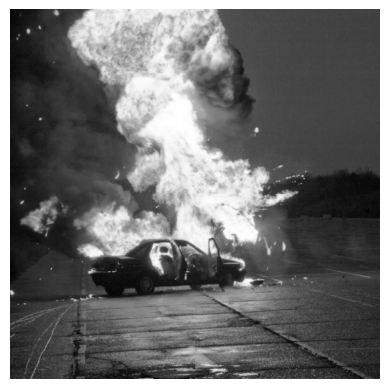

In [56]:
citra_gray = cv.cvtColor(merge, cv.COLOR_RGB2GRAY)
plt.imshow(citra_gray, cmap='gray')
plt.axis('off')

ekualisasi

Proses 5 dibutuhkan karena kode ini berfungsi untuk menjalankan teknik Histogram Equalization untuk meningkatkan kontras gambar. Proses dimulai dengan menghitung distribusi frekuensi setiap tingkat keabuan (histogram), yang kemudian diakumulasikan menjadi Cumulative Distribution Function (CDF). CDF ini berfungsi sebagai pemetaan baru untuk meratakan sebaran warna yang awalnya mungkin terlalu gelap atau terlalu terang. Selanjutnya, nilai CDF tersebut dinormalisasi ke rentang 0-255 agar kembali menjadi format citra yang valid. Dengan memetakan ulang setiap piksel lama ke nilai baru yang lebih merata, area gambar yang detailnya tersembunyi karena kontras rendah akan menjadi lebih jelas dan tajam. Hasil akhirnya memperlihatkan gambar yang kini memiliki pencahayaan dan detail yang lebih seimbang.

(np.float64(-0.5), np.float64(689.5), np.float64(689.5), np.float64(-0.5))

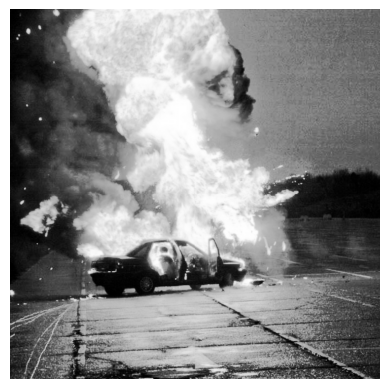

In [57]:
def ekualisasi(citra):
    height, width = citra.shape

    # histogram
    hist = np.zeros(256, dtype=int)

    for i in range(height):
        for j in range(width):
            val = int(citra[i, j])
            hist[val] += 1

    # CDF
    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]

    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]

    # CDF min
    cdf_min = 0
    for i in range(256):
        if cdf[i] != 0:
            cdf_min = cdf[i]
            break

    # normalisasi
    cdf_normal = np.zeros(256)

    for i in range(256):
        cdf_normal[i] = np.round(
            (cdf[i] - cdf_min) / ((height * width) - cdf_min) * 255
        )

    hasil = np.zeros((height, width))

    for i in range(height):
        for j in range(width):
            val = int(citra[i, j])
            hasil[i, j] = cdf_normal[val]

    return hasil

hasil_ekual = ekualisasi(citra_gray)

plt.imshow(hasil_ekual, cmap='gray')
plt.axis('off')

histogram sebelum & sesudah ekualisasi

Proses 6 dibutuhkan karena kode ini berfungsi untuk menghitung sebaran intensitas warna dalam sebuah gambar dengan cara menelusuri setiap piksel satu per satu. Untuk setiap nilai piksel yang ditemukan (dari rentang 0 hingga 255), program akan menambah hitungan pada indeks yang sesuai dalam daftar histo. Hasilnya adalah representasi statistik yang menunjukkan berapa banyak piksel gelap, menengah, atau terang yang ada dalam gambar tersebut. Pada bagian visualisasi, kode ini membandingkan kondisi gambar sebelum dan sesudah proses ekualisasi menggunakan diagram batang. Histogram berwarna hijau (before) menunjukkan distribusi yang menumpuk di area tertentu (kontras rendah), sedangkan histogram merah (after) menunjukkan distribusi yang lebih menyebar luas ke seluruh rentang intensitas. Perbandingan ini secara visual membuktikan bahwa teknik ekualisasi berhasil meratakan intensitas piksel untuk menghasilkan gambar dengan kontras yang lebih tajam dan detail yang lebih menonjol.

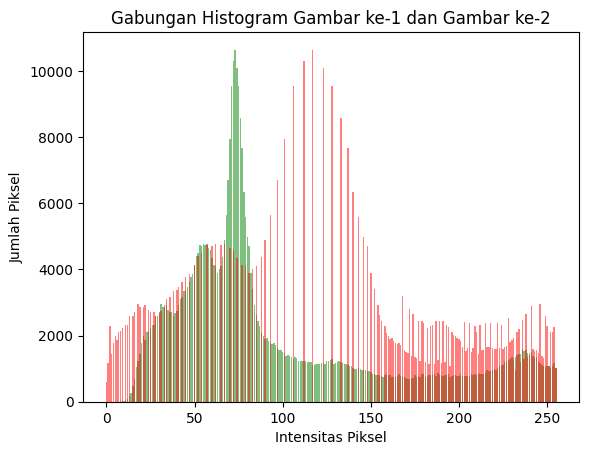

In [58]:
def histogram(img):
    histo = [0] * 256
    for row in img:
        for pixel in row:
            histo[int(pixel)] += 1   
    return histo                   


before = histogram(citra_gray)
after = histogram(hasil_ekual)

plt.bar(range(256), before, alpha=0.5, color='green')
plt.bar(range(256), after, alpha=0.5, color='red')

plt.title("Gabungan Histogram Gambar ke-1 dan Gambar ke-2")
plt.ylabel("Jumlah Piksel")
plt.xlabel("Intensitas Piksel")

plt.show()

citra untuk spesifikasi

Proses 7 dibutuhkan karena kode ini berfungsi untuk memuat dan menampilkan dua buah gambar yang berbeda secara berdampingan dalam mode grayscale. cv.imread agar program membaca file Windut.png dan Bunga.png, yang kemudian segera dikonversi menggunakan cv.cvtColor menjadi format satu kanal warna untuk menghilangkan informasi warna aslinya. Proses visualisasinya menggunakan plt.subplot(1,2,n) yang membagi area tampilan menjadi satu baris dan dua kolom. Gambar "Windut" diletakkan pada kolom pertama dan gambar "Bunga Ireng" pada kolom kedua, keduanya dirender dengan cmap='gray'. Penggunaan plt.axis('off') pada masing-masing gambar bertujuan untuk menyembunyikan sumbu koordinat agar fokus utama hanya tertuju pada konten visual kedua objek tersebut.

(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

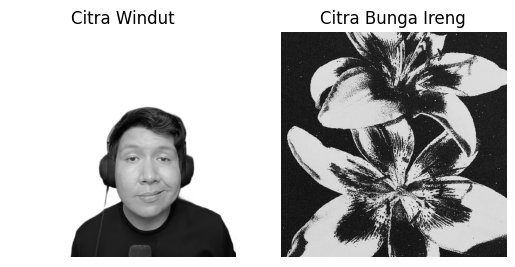

In [59]:
windut = cv.imread("Assets/Windut.png")
bunga = cv.imread("Assets/Bunga.png")
windut = cv.cvtColor(windut, cv.COLOR_BGR2GRAY)
bunga = cv.cvtColor(bunga, cv.COLOR_BGR2GRAY)

plt.subplot(1,2,1)
plt.imshow(windut, cmap='gray')
plt.title("Citra Windut")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(bunga, cmap='gray')
plt.title("Citra Bunga Ireng")
plt.axis('off')

spesifikasi

Proses 8 dibutuhkan karena kode ini berfungsi untuk mengubah karakteristik pencahayaan citra asal agar mengikuti gaya distribusi warna dari citra target. Secara teknis, program menghitung histogram dan Cumulative Distribution Function (CDF) dari kedua gambar, lalu menormalisasinya agar berada dalam rentang yang sebanding. Inti dari proses ini terletak pada bagian mapping histogram, di mana setiap tingkat keabuan pada citra asal dicocokkan dengan nilai pada citra target yang memiliki nilai CDF paling mendekati. Dengan memetakan ulang piksel berdasarkan kemiripan akumulasi distribusi ini, citra "Windut" akan memiliki kontras, kecerahan, dan suasana visual yang serupa dengan citra "Bunga". Hasil akhirnya adalah gambar baru yang mempertahankan bentuk objek asli namun dengan pencahayaan yang dipinjam dari gambar referensi.

Text(0.5, 1.0, 'Hasil Spesifikasi')

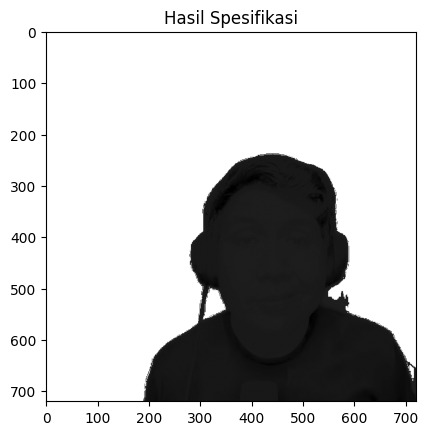

In [60]:
def spesifikasi(citra_asal, citra_target):

    #histogram
    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    # histogram citra asal
    for row in citra_asal:
        for pixel in row:
            hist_asal[int(pixel)] += 1

    # histogram citra target
    for row in citra_target:
        for pixel in row:
            hist_target[int(pixel)] += 1

    # CDF
    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)

    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i-1] + hist_asal[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]

    # normalisasi
    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]

    #mapping histogram
    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):
        min_selisih = abs(cdf_asal[i] - cdf_target[0])
        index = 0

        for j in range(256):
            selisih = abs(cdf_asal[i] - cdf_target[j])

            if selisih < min_selisih:
                min_selisih = selisih
                index = j

        map_hist[i] = index
    height, width = citra_asal.shape
    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            val = int(citra_asal[i, j])
            hasil[i, j] = map_hist[val]

    return hasil

hasil_spes = spesifikasi(windut, bunga)
plt.imshow(hasil_spes, cmap='gray')
plt.title("Hasil Spesifikasi")

histogram spesifikasi

Proses 9 dibutuhkan karena kode ini berfungsi untuk menghitung dan memvisualisasikan distribusi intensitas piksel dari gambar hasil proses Histogram Specification sebelumnya. Fungsi buat_hist bekerja dengan menelusuri setiap koordinat piksel pada gambar, mengambil nilai intensitasnya (0–255), dan menjumlahkan kemunculannya ke dalam sebuah daftar (list). Setelah data frekuensi terkumpul, fungsi plot_histogram menggunakan pustaka Matplotlib untuk membuat diagram batang. Dalam konteks ini, histogram berwarna merah (hist_hasil) akan menunjukkan bentuk distribusi yang sudah berubah, bentuknya tidak akan lagi seperti histogram asli "Windut", melainkan sudah menyerupai atau mendekati bentuk distribusi "Bunga". 

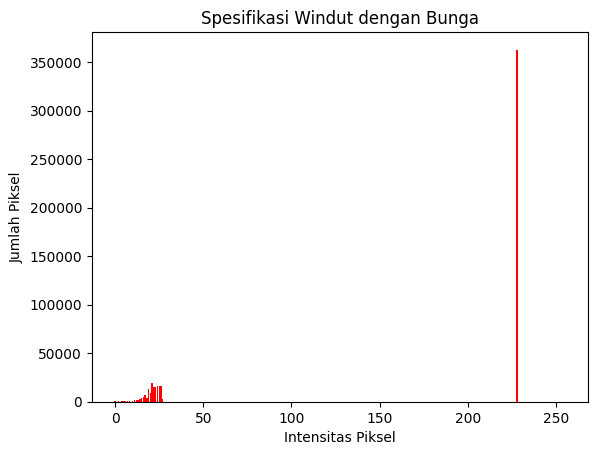

In [61]:
def buat_hist(citra):
    histogram = [0] * 256
    height = len(citra)
    width = len(citra[0]) if height > 0 else 0

    for i in range(height):
        for j in range(width):
            val = int(citra[i][j])
            histogram[val] += 1

    return histogram

def plot_histogram(histogram, title, ImgColor):
    plt.xlabel("Intensitas Piksel")
    plt.title(title)
    plt.ylabel("Jumlah Piksel")
    plt.bar(range(256), histogram, color=ImgColor, width=0.8)
    plt.show()


# histogram setelah spesifikasi
hist_hasil = buat_hist(hasil_spes)

plot_histogram(hist_hasil, "Spesifikasi Windut dengan Bunga", "red")

masking

Proses 10 dibutuhkan karena kode ini berfungsi untuk proses penggabungan dua citra teknik masking. Tahapan dimulai dengan mengidentifikasi ukuran minimum antara citra hasil spesifikasi (hasil_spes) dan citra ekualisasi (hasil_ekual) untuk menghindari kesalahan indeks, kemudian memotong keduanya agar memiliki dimensi yang identik. Selanjutnya, sebuah kanvas kosong dibuat untuk menampung hasil penggabungan yang diproses piksel demi piksel menggunakan logika kondisional. Jika suatu piksel pada citra objek memiliki intensitas di atas ambang batas 200, maka sistem akan mengambil informasi visual dari citra ekual. Sebaliknya, jika intensitasnya lebih rendah, piksel dari citra crop tetap dipertahankan. Hasil akhirnya adalah citra yang menggabungkan elemen dari dua proses pengolahan sebelumnya dalam satu tampilan.

(np.float64(-0.5), np.float64(689.5), np.float64(689.5), np.float64(-0.5))

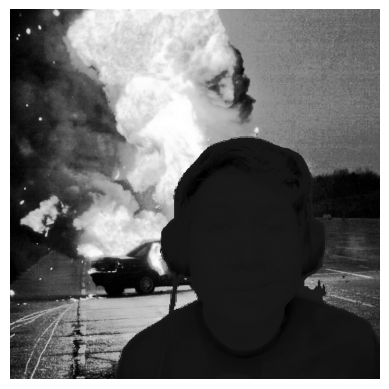

In [71]:
h = min(hasil_spes.shape[0], hasil_ekual.shape[0])
w = min(hasil_spes.shape[1], hasil_ekual.shape[1])

crop = hasil_spes[:h, :w]
ekual = hasil_ekual[:h, :w]

# masking
masking = np.zeros_like(crop)

for i in range(h):
    for j in range(w):
        if crop[i, j] > 200:   # threshold bisa kamu ubah
            masking[i, j] = ekual[i, j]   # ambil dari hasil ekual
        else:
            masking[i, j] = crop[i, j]    # sisanya dari hasil_crop

plt.imshow(masking, cmap='gray')
plt.axis('off')

Proses 11 dibutuhkan karena kode ini berfungsi untuk melakukan proses penggabungan dua gambar diikuti dengan penyesuaian kecerahan. Pertama, program menyamakan dimensi antara gambar windut (objek) dan hasil_ekual (latar belakang) agar ukurannya identik. Melalui perulangan piksel, kode memeriksa nilai intensitas pada gambar objek: jika piksel berwarna putih (di atas ambang batas 250), maka posisi tersebut diisi oleh piksel dari latar belakang, jika tidak, piksel asli objek tetap dipertahankan. Setelah proses penggabungan selesai, dilakukan manipulasi pencerahan dengan menambahkan nilai 10 pada setiap piksel hasil, lengkap dengan fungsi clipping agar nilai tetap berada dalam rentang valid (0-255) sebelum akhirnya ditampilkan dalam grayscale.

(np.float64(-0.5), np.float64(689.5), np.float64(689.5), np.float64(-0.5))

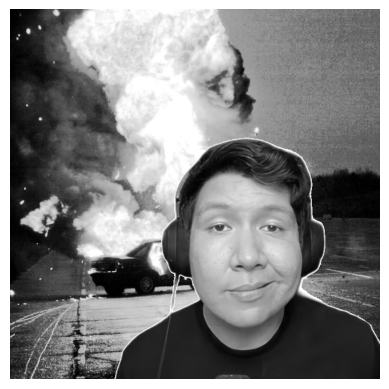

In [62]:
h = min(windut.shape[0], hasil_ekual.shape[0])
w = min(windut.shape[1], hasil_ekual.shape[1])

obj = windut[:h, :w]
bg  = hasil_ekual[:h, :w]

hasil = np.zeros((h, w))

for i in range(h):
    for j in range(w):
        # kalau putih → ambil background
        if obj[i, j] > 250:   # threshold putih
            hasil[i, j] = bg[i, j]
        else:
            # selain itu ambil objek (wajah)
            hasil[i, j] = obj[i, j]

for i in range(h):
    for j in range(w):
        val = hasil[i, j] * 1.0 + 10

        if val > 255: val = 255
        if val < 0: val = 0

        hasil[i, j] = np.round(val)

plt.imshow(hasil, cmap='gray')
plt.axis('off')


citra langit jadi grayscale

Proses 12 dibutuhkan karena kode ini berfungsi untuk membaca gambar dan mengubah ruang warnanya. Pertama, gambar Langit.png dimuat menggunakan OpenCV yang secara standar menggunakan format BGR. Agar warna tampil akurat saat divisualisasikan, format tersebut dikonversi menjadi RGB. Selanjutnya, citra berwarna tersebut diubah menjadi Grayscale (skala abu-abu) untuk menyederhanakan data piksel menjadi satu saluran intensitas cahaya saja. Terakhir, gambar ditampilkan dalam format hitam-putih menggunakan Matplotlib tanpa menyertakan sumbu koordinat pada bingkainya.

(np.float64(-0.5), np.float64(734.5), np.float64(489.5), np.float64(-0.5))

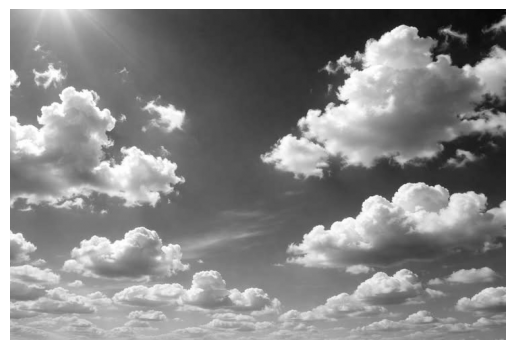

In [63]:
citra_langit = cv.imread("Assets/Langit.png")
citra_langit = cv.cvtColor(citra_langit, cv.COLOR_BGR2RGB)
langit_gray = cv.cvtColor(citra_langit, cv.COLOR_RGB2GRAY)
plt.imshow(langit_gray, cmap='gray')
plt.axis('off')

spesifikasi windut dengan langit

Proses 13 dibutuhkan karena kode ini berfungsi untuk mengubah distribusi warna citra asal agar mengikuti distribusi warna citra target. Proses dimulai dengan menghitung histogram dan fungsi distribusi kumulatif (CDF) dari kedua citra, di mana nilai piksel tertentu dapat diabaikan agar tidak mengacaukan perhitungan. Setelah CDF dinormalisasi, kode melakukan pemetaan (mapping) dengan mencari nilai intensitas pada citra target yang memiliki nilai CDF paling mendekati nilai CDF pada citra asal. Hasil akhirnya adalah citra baru yang secara visual memiliki karakteristik pencahayaan atau kontras yang serupa dengan citra referensi (langit_gray).

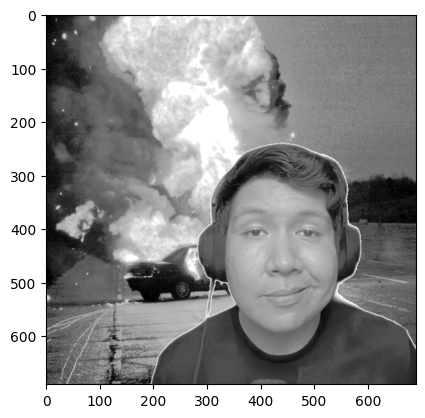

In [64]:
def sps(citra_asal, citra_target, ignore_val=0):
    # histogram
    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    for row in citra_asal:
        for pixel in row:
            if ignore_val is not None and pixel == ignore_val:
                continue
            hist_asal[int(pixel)] += 1

    # histogram citra target
    for row in citra_target:
        for pixel in row:
            hist_target[int(pixel)] += 1

    # CDF
    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)

    if ignore_val == 0:
        cdf_asal[0] = 0
    else:
        cdf_asal[0] = hist_asal[0]
    
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i-1] + hist_asal[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]

    # normalisasi
    total_asal = cdf_asal[-1]
    total_target = cdf_target[-1]
    
    if total_asal > 0:
        cdf_asal = cdf_asal / total_asal
    if total_target > 0:
        cdf_target = cdf_target / total_target

    # mapping histogram
    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):
        if i == ignore_val and ignore_val is not None:
            map_hist[i] = ignore_val
            continue
            
        min_selisih = abs(cdf_asal[i] - cdf_target[0])
        index = 0

        for j in range(256):
            selisih = abs(cdf_asal[i] - cdf_target[j])
            if selisih < min_selisih:
                min_selisih = selisih
                index = j
        map_hist[i] = index
        
    height, width = citra_asal.shape
    hasil_img = np.zeros((height, width), dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            val = int(citra_asal[i, j])
            hasil_img[i, j] = map_hist[val]
    return hasil_img

hasil_sps = sps(hasil, langit_gray, ignore_val=0)
plt.imshow(hasil_sps, cmap='gray')


histogram

Proses 14 dibutuhkan karena kode ini berfungsi untuk menghitung dan memvisualisasikan distribusi frekuensi nilai piksel dari sebuah gambar menggunakan Histogram. Fungsi buat_histo bekerja dengan cara menginisialisasi daftar berisi 256 elemenyang semuanya bernilai nol. Melalui dua lapis perulangan, setiap piksel pada citra diperiksa intensitasnya, kemudian posisi yang sesuai pada daftar akan ditambah satu (increment). Setelah data terkumpul, hasilnya ditampilkan dalam bentuk diagram batang berwarna merah menggunakan Matplotlib. 

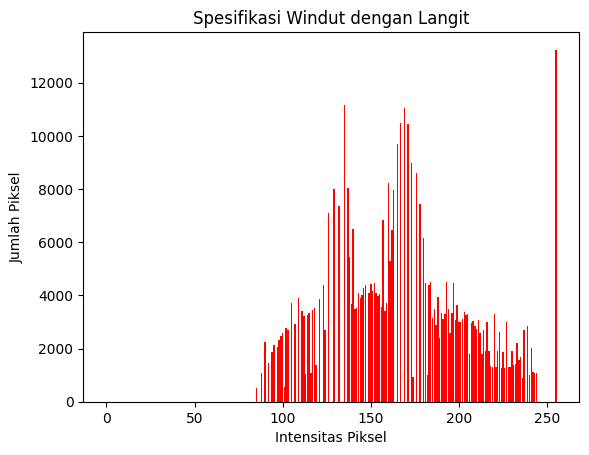

In [65]:
def buat_histo(citra):
    histogram = [0] * 256
    h = citra.shape[0]
    w = citra.shape[1]

    for i in range(h):
        for j in range(w):
            val = int(citra[i, j])
            histogram[val] += 1

    return histogram

hist_spes = buat_histo(hasil_sps)
plt.bar(range(256), hist_spes, color='red')
plt.title("Spesifikasi Windut dengan Langit")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.show()


buat berwarna

Proses 15 dibutuhkan karena kode ini berfungsi untuk melakukan proses penggantian latar belakang pada citra berwarna dengan teknik masking. Langkah pertama adalah membuat variabel windah untuk mengekstrak objek dari latar belakang asliny, jika piksel pada referensi windut bernilai di atas 250 (dianggap latar belakang putih), maka piksel tersebut diubah menjadi hitam (0), jika tidak, warna asli dari windut_warna dipertahankan. Setelah melakukan pemotongan tepi menggunakan fungsi clip, kode kemudian melakukan penggabungan akhir, setiap piksel yang berwarna hitam pada windah akan digantikan oleh piksel dari citra merge (latar belakang baru), sementara piksel objek tetap menggunakan warna aslinya. Hasil akhirnya adalah gambar subjek yang telah "ditempel" ke latar belakang baru secara presisi di tingkat piksel.

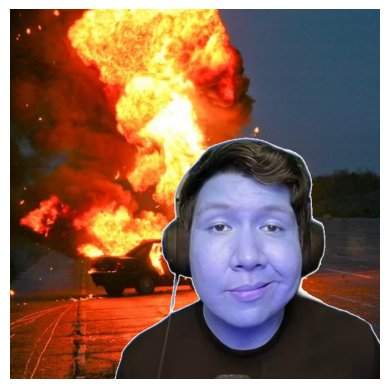

In [66]:
windut_warna = cv.imread("Assets/Windut.png")
windah = np.zeros_like(windut_warna)

for i in range(windut_warna.shape[0]):
    for j in range(windut_warna.shape[1]):
        if windut[i, j] >= 250:
            windah[i, j] = 0
        else:
            windah[i, j] = windut_warna[i, j]

windah = clip(windah, 0, 30, 0, 30)

windut_citra = np.zeros_like(windah)

for i in range(windah.shape[0]):
    for j in range(windah.shape[1]):
        if np.all(windah[i, j] == 0):
            windut_citra[i, j] = merge[i, j]
        else:
            windut_citra[i, j] = windah[i, j]

plt.imshow(windut_citra)
plt.axis('off')
plt.show()

Proses 16 dibutuhkan karena kode ini berfungsi untuk pemisahan objek untuk menggabungkan dua citra berwarna. Pertama, kode membuat kanvas kosong windah dan memindahkan piksel dari windut_warna hanya jika piksel pada referensi windut tidak berwarna putih (di bawah ambang 250), sehingga objek terisolasi dengan latar belakang hitam. Setelah dilakukan pemotongan tepi melalui fungsi clip, kode melakukan pemindaian piksel demi piksel, jika suatu piksel di windah berwarna hitam total (0,0,0), maka posisi tersebut diisi oleh piksel dari citra merge (sebagai latar belakang baru), jika tidak, piksel objek asli dipertahankan. Hasil akhirnya adalah komposisi citra di mana objek utama diletakkan di atas latar belakang baru, yang kemudian ditampilkan tanpa sumbu koordinat.

(np.float64(-0.5), np.float64(689.5), np.float64(689.5), np.float64(-0.5))

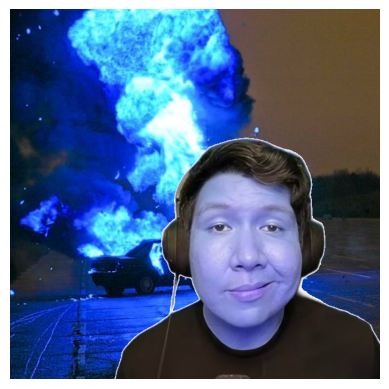

In [67]:
windut_warna = cv.imread("Assets/Windut.png")
windah = np.zeros_like(windut_warna)

for i in range(windah.shape[0]):
    for j in range(windut_warna.shape[1]):
        if windut[i, j] < 250:  
            windah[i, j] = windut_warna[i, j]

windah = clip(windah, 0, 30, 0, 30)

merge = cv.cvtColor(merge, cv.COLOR_RGB2BGR)
hasil_windah = np.zeros_like(windah)

for i in range(windah.shape[0]):
    for j in range(windah.shape[1]):
        if windah[i, j, 0] == 0 and windah[i, j, 1] == 0 and windah[i, j, 2] == 0:
            hasil_windah[i, j] = merge[i, j]
        else:
            hasil_windah[i, j] = windah[i, j]

plt.imshow(hasil_windah)
plt.axis('off')

KESIMPULAN

Rangkaian kode ini secara keseluruhan merupakan implementasi pengolahan citra digital yang berfokus pada teknik penggabungan dua gambar yang berbeda menjadi satu kesatuan. Proses ini dimulai dengan tahap cropping dan dikonversi ruang warnanya untuk menyamakan dimensi serta format data. Selanjutnya, dilakukan pemisahan objek dari latar belakang menggunakan metode thresholding (ambang batas) dan pemantauan distribusi warna melalui histogram. Kemudian dilakukan Histogram Specification, yang menyelaraskan pencahayaan dan kontras objek agar sesuai dengan atmosfer latar belakang barunya. Pada tahap akhir, dilakukan proses masking piksel untuk menumpuk objek di atas latar belakang baru secara presisi. Dengan memeriksa setiap koordinat warna, program lalu memutuskan kapan harus menampilkan piksel objek dan kapan harus menampilkan piksel latar belakang, menghasilkan sebuah citra yang terlihat menyatu secara visual.